In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [41]:
df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Dataset loaded!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded!
Rows: 7043
Columns: 21


In [42]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [43]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [44]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [46]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].isnull().sum())

11


In [47]:
df = df.dropna(subset=['TotalCharges'])
print("Remaining rows:", len(df))

Remaining rows: 7032


C:\Users\RaghavJ\AppData\Local\Temp\ipykernel_12496\1231448056.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


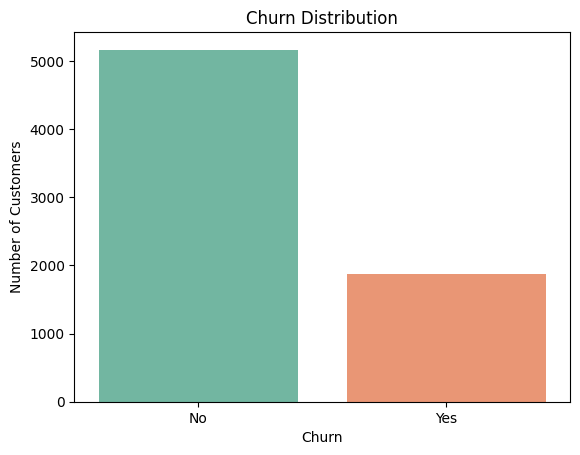

In [48]:
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

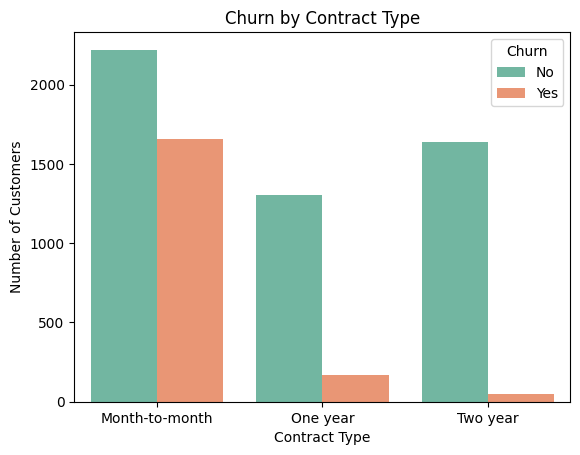

In [49]:
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

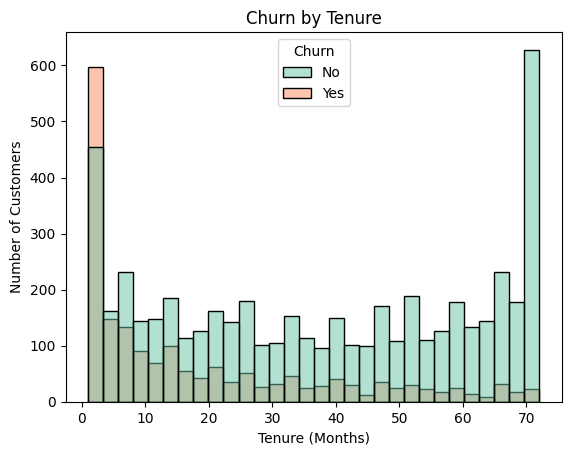

In [50]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette='Set2')
plt.title('Churn by Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()

In [51]:
df = df.drop(columns=['customerID'])
print("Columns remaining:", df.shape[1])

Columns remaining: 20


In [52]:
yes_no_columns = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                  'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                  'TechSupport', 'StreamingTV', 'StreamingMovies',
                  'PaperlessBilling', 'Churn']

for col in yes_no_columns:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

print("Done! Sample:")
print(df[['Partner', 'Churn']].head())

Done! Sample:
   Partner  Churn
0        1      0
1        0      0
2        0      1
3        0      0
4        0      1


In [53]:
print(df.select_dtypes(include='object').columns.tolist())

['gender', 'InternetService', 'Contract', 'PaymentMethod']


C:\Users\RaghavJ\AppData\Local\Temp\ipykernel_12496\3086284521.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include='object').columns.tolist())


In [54]:
df = pd.get_dummies(df, columns=['gender', 'InternetService', 'Contract', 'PaymentMethod'], drop_first=True)
print("Columns now:", df.shape[1])
print(df.head(2))

Columns now: 24
   SeniorCitizen  Partner  Dependents  tenure  PhoneService  MultipleLines  \
0              0        1           0       1             0            NaN   
1              0        0           0      34             1            0.0   

   OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  ...  \
0             0.0           1.0               0.0          0.0  ...   
1             1.0           0.0               1.0          0.0  ...   

   TotalCharges  Churn  gender_Male  InternetService_Fiber optic  \
0         29.85      0        False                        False   
1       1889.50      0         True                        False   

   InternetService_No  Contract_One year  Contract_Two year  \
0               False              False              False   
1               False               True              False   

   PaymentMethod_Credit card (automatic)  PaymentMethod_Electronic check  \
0                                  False                        

In [55]:
X = df.drop(columns=['Churn'])
y = df['Churn']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7032, 23)
y shape: (7032,)


In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 5625
Testing rows: 1407


In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling done!")

Scaling done!


In [39]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained successfully!")

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
print(X_train.shape)
import numpy as np
print("Missing values in X_train:", np.isnan(X_train).sum())

In [ ]:
import pandas as pd
print(df.isnull().sum()[df.isnull().sum() > 0])

In [ ]:
yes_no_columns = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                  'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                  'TechSupport', 'StreamingTV', 'StreamingMovies',
                  'PaperlessBilling', 'Churn']

for col in yes_no_columns:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 
                           'No phone service': 0, 
                           'No internet service': 0})

print("Done!")
print(df[yes_no_columns].isnull().sum().sum(), "missing values remaining")

In [ ]:
# Fill any remaining missing values with 0
df = df.fillna(0)
print("Missing values after fillna:", df.isnull().sum().sum())

In [58]:
import numpy as np
print("NaN in X_train:", np.isnan(X_train).sum())
print("NaN in X_test:", np.isnan(X_test).sum())

NaN in X_train: 7947
NaN in X_test: 1853


In [59]:
import numpy as np

# Fill NaN directly in X_train and X_test
X_train = np.nan_to_num(X_train, nan=0)
X_test = np.nan_to_num(X_test, nan=0)

print("NaN in X_train:", np.isnan(X_train).sum())
print("NaN in X_test:", np.isnan(X_test).sum())

NaN in X_train: 0
NaN in X_test: 0


In [60]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [61]:
y_pred = model.predict(X_test)
print("Predictions done!")
print("First 10 predictions:", y_pred[:10])
print("Actual values:       ", list(y_test[:10]))

Predictions done!
First 10 predictions: [0 0 1 0 0 0 0 1 0 0]
Actual values:        [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]


In [62]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy * 100, 2), "%")
print()
print(classification_report(y_test, y_pred))

Accuracy: 78.82 %

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



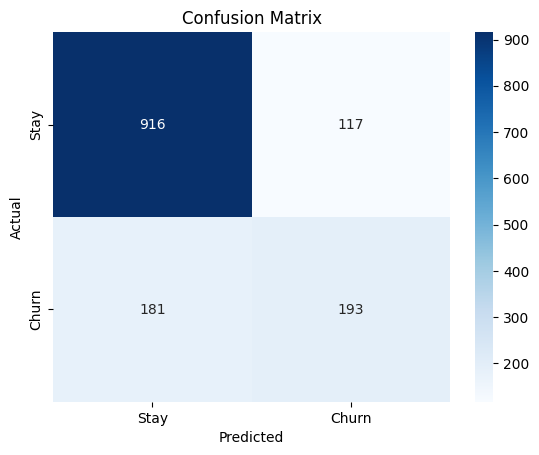

In [63]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay', 'Churn'],
            yticklabels=['Stay', 'Churn'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [64]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [65]:
from sklearn.metrics import accuracy_score, classification_report

rf_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", round(accuracy * 100, 2), "%")
print()
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 78.82 %

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [66]:
rf_balanced = RandomForestClassifier(n_estimators=100, 
                                      class_weight='balanced',
                                      random_state=42)
rf_balanced.fit(X_train, y_train)
rf_balanced_pred = rf_balanced.predict(X_test)

accuracy = accuracy_score(y_test, rf_balanced_pred)
print("Balanced Random Forest Accuracy:", round(accuracy * 100, 2), "%")
print()
print(classification_report(y_test, rf_balanced_pred))

Balanced Random Forest Accuracy: 78.61 %

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.46      0.53       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.77      1407



In [67]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, 
                           scale_pos_weight=3,
                           random_state=42,
                           eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

accuracy = accuracy_score(y_test, xgb_pred)
print("XGBoost Accuracy:", round(accuracy * 100, 2), "%")
print()
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 73.92 %

              precision    recall  f1-score   support

           0       0.86      0.77      0.81      1033
           1       0.51      0.66      0.57       374

    accuracy                           0.74      1407
   macro avg       0.68      0.71      0.69      1407
weighted avg       0.77      0.74      0.75      1407



C:\Users\RaghavJ\AppData\Local\Temp\ipykernel_12496\3329231267.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='Blues_r')


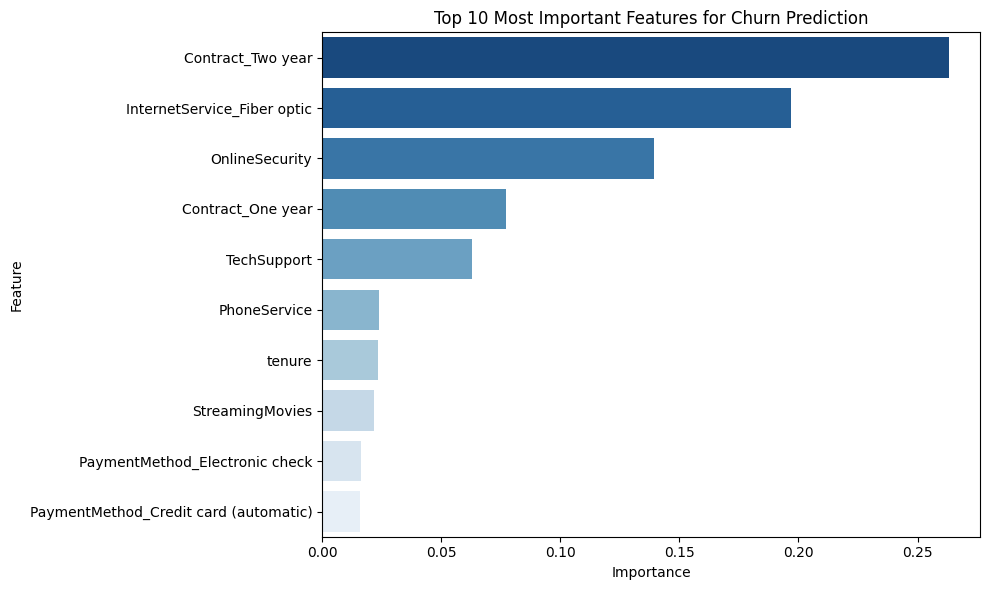

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = df.drop(columns=['Churn']).columns
importances = xgb_model.feature_importances_

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='Blues_r')
plt.title('Top 10 Most Important Features for Churn Prediction')
plt.tight_layout()
plt.show()

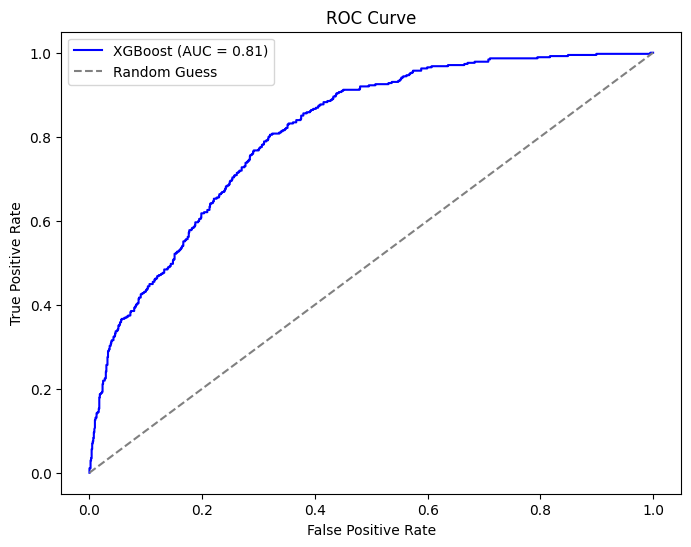

AUC Score: 0.8119


In [69]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = xgb_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'XGBoost (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

print("AUC Score:", round(auc_score, 4))

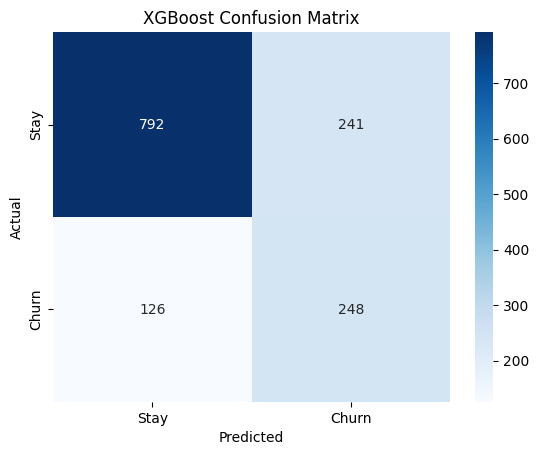

In [70]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay', 'Churn'],
            yticklabels=['Stay', 'Churn'])
plt.title('XGBoost Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

C:\Users\RaghavJ\AppData\Local\Temp\ipykernel_12496\4066481279.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='Blues_d', ax=ax1)
C:\Users\RaghavJ\AppData\Local\Temp\ipykernel_12496\4066481279.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=churn_recall, palette='Oranges_d', ax=ax2)


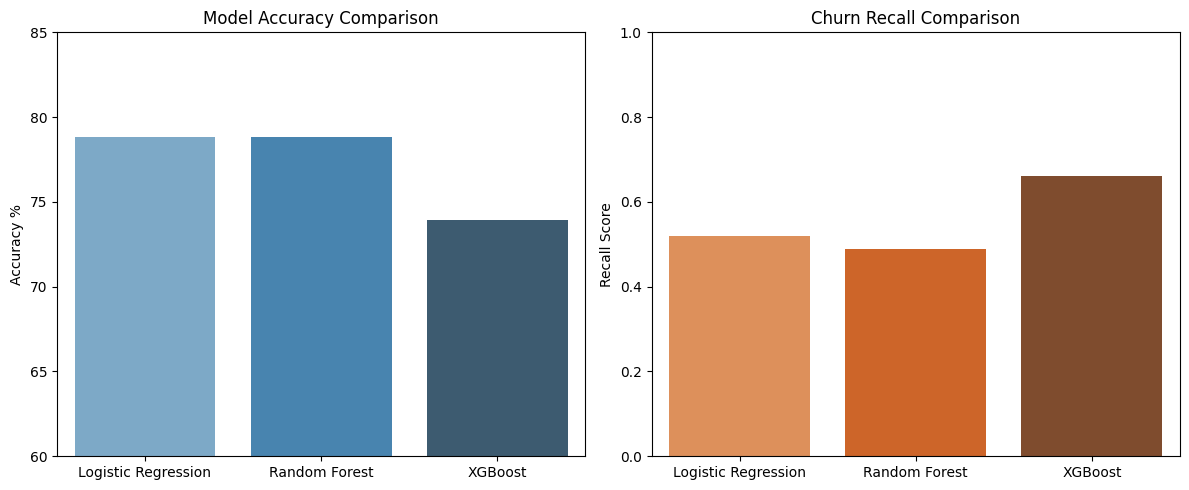

In [71]:
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
accuracies = [78.82, 78.82, 73.92]
churn_recall = [0.52, 0.49, 0.66]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=models, y=accuracies, palette='Blues_d', ax=ax1)
ax1.set_title('Model Accuracy Comparison')
ax1.set_ylabel('Accuracy %')
ax1.set_ylim(60, 85)

sns.barplot(x=models, y=churn_recall, palette='Oranges_d', ax=ax2)
ax2.set_title('Churn Recall Comparison')
ax2.set_ylabel('Recall Score')
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()